In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns
from tqdm import tqdm
import re

In [5]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm

# =====================================================================
# 1. DATASET CLASS
# =====================================================================

class Camelyon17Dataset(Dataset):
    def __init__(self, metadata_df, patches_dir, transform=None):
        """
        Args:
            metadata_df: DataFrame with columns [patient, node, x_coord, y_coord, tumor, center]
            patches_dir: Path to patches directory
            transform: Image transformations
        """
        self.metadata = metadata_df.reset_index(drop=True)
        self.patches_dir = patches_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        
        # Construct image path
        patient = str(row['patient'])
        if len(patient) == 1:
            patient = '00'+patient
        elif len(patient) == 2:
            patient = '0'+patient
            
        node = row['node']
        x = row['x_coord']
        y = row['y_coord']
        
        img_path = os.path.join(
            self.patches_dir,
            f'patient_{patient}_node_{node}',
            f'patch_patient_{patient}_node_{node}_x_{x}_y_{y}.png'
        )
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(row['tumor'], dtype=torch.long)
        
        return image, label

# =====================================================================
# 2. MODEL ARCHITECTURE
# =====================================================================

class Camelyon17CNN(nn.Module):
    def __init__(self, pretrained=True, freeze_backbone=True):
        super(Camelyon17CNN, self).__init__()
        
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        
        if pretrained:
            self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        else:
            self.backbone = efficientnet_b0(weights=None)
        
        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # Get feature dimension
        self.feature_dim = self.backbone.classifier[1].in_features
        
        # Remove final classifier
        self.backbone.classifier = nn.Identity()
        
        # Feature extractor with regularization
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(self.feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
        )
        
        # Output layer (renamed to fc2 for compatibility with score feature code)
        self.fc2 = nn.Linear(256, 1)
    
    def get_features(self, x):
        """Extract features before final classification layer"""
        with torch.no_grad():
            x = self.backbone(x)
        x = self.classifier(x)
        return x
    
    def forward(self, x):
        features = self.get_features(x)
        x = self.fc2(features)
        return x

# =====================================================================
# 3. TRAINING FUNCTIONS
# =====================================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.backbone.eval()
    model.classifier.train()
    model.fc2.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(train_loader, desc='Training'):
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Validation'):
            inputs = inputs.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# =====================================================================
# 4. SCORE FEATURE DATASET
# =====================================================================

class ScoreFeatureDataset(Dataset):
    def __init__(self, cnn_scores, features, target_decoy_scores, labels):
        self.cnn_scores = cnn_scores
        self.features = features
        self.target_decoy_scores = target_decoy_scores
        self.labels = labels
        
    def __len__(self):
        return len(self.cnn_scores)
    
    def __getitem__(self, idx):
        return (
            self.cnn_scores[idx],
            self.features[idx],
            self.target_decoy_scores[idx],
            self.labels[idx]
        )

def collect_negative_scores(model, dataset, device='cuda'):
    """Collect scores for negative (non-tumor) samples"""
    negative_scores = []
    
    model.eval()
    data_loader = DataLoader(dataset, batch_size=64, shuffle=False)
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Collecting negative scores'):
            images = images.to(device)
            labels = labels.to(device)
            
            features = model.get_features(images)
            scores = model.fc2(features)
            
            # Get scores for negative samples (tumor=0)
            neg_mask = labels == 0
            if neg_mask.sum() > 0:
                neg_scores = scores[neg_mask].cpu()
                negative_scores.append(neg_scores)
    
    if negative_scores:
        negative_scores = torch.cat(negative_scores).numpy().flatten()
        print(f"Collected {len(negative_scores)} negative scores")
    else:
        negative_scores = np.array([])
        print("No negative scores collected")
    return negative_scores

def create_score_feature_dataset(dataset, cnn_model, negative_scores_pool, device='cuda'):
    """Create dataset with CNN scores, features, and target-decoy scores"""
    cnn_scores_list = []
    features_list = []
    target_decoy_list = []
    labels_list = []
    
    cnn_model.eval()
    data_loader = DataLoader(dataset, batch_size=64, shuffle=False)
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Creating score feature dataset'):
            images = images.to(device)
            
            features = cnn_model.get_features(images)
            scores = cnn_model.fc2(features)
            
            scores_cpu = scores.cpu()
            features_cpu = features.cpu()
            
            # Create target-decoy scores
            target_decoy_scores = scores_cpu.clone()
            
            for i, label in enumerate(labels):
                if label.item() == 1 and len(negative_scores_pool) > 0:
                    # For positive samples, replace with random negative score
                    random_neg_score = np.random.choice(negative_scores_pool)
                    target_decoy_scores[i] = torch.tensor(
                        random_neg_score,
                        dtype=target_decoy_scores.dtype
                    )
            
            cnn_scores_list.append(scores_cpu)
            features_list.append(features_cpu)
            target_decoy_list.append(target_decoy_scores)
            labels_list.append(labels)
    
    all_cnn_scores = torch.cat(cnn_scores_list)
    all_features = torch.cat(features_list)
    all_target_decoy = torch.cat(target_decoy_list)
    all_labels = torch.cat(labels_list)
    
    return ScoreFeatureDataset(all_cnn_scores, all_features, all_target_decoy, all_labels)

# =====================================================================
# 5. MAIN PIPELINE
# =====================================================================

def main():
    # Configuration
    METADATA_PATH = '/kaggle/input/camelyon17/metadata.csv'
    PATCHES_DIR = '/kaggle/input/camelyon17/patches'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_EPOCHS = 10
    BATCH_SIZE = 32
    LEARNING_RATE = 5e-5
    
    print("="*70)
    print("CAMELYON17 CLASSIFICATION PIPELINE")
    print("="*70)
    print(f"Device: {DEVICE}")
    
    # Load metadata
    print("\n1. Loading metadata...")
    metadata = pd.read_csv(METADATA_PATH)
    print(f"Total samples: {len(metadata)}")
    print(f"\nClass distribution:")
    print(metadata['tumor'].value_counts())
    print(f"\nCenter distribution:")
    print(metadata['center'].value_counts().sort_index())
    
    # Split by center
    print("\n2. Splitting data by center...")
    train_df = metadata[metadata['center'].isin([0, 1, 2])].copy()
    val_df = metadata[metadata['center'] == 3].copy()
    test_df = metadata[metadata['center'] == 4].copy()
    
    print(f"Train: {len(train_df)} samples (centers 0, 1, 2)")
    print(f"Val:   {len(val_df)} samples (center 3)")
    print(f"Test:  {len(test_df)} samples (center 4)")
    
    # Define transforms
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    # Create datasets
    print("\n3. Creating datasets...")
    train_dataset = Camelyon17Dataset(train_df, PATCHES_DIR, train_transform)
    val_dataset = Camelyon17Dataset(val_df, PATCHES_DIR, val_transform)
    test_dataset = Camelyon17Dataset(test_df, PATCHES_DIR, val_transform)
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                             shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                           shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
                            shuffle=False, num_workers=2)
    
    # Create model
    print("\n4. Creating model...")
    model = Camelyon17CNN(pretrained=True, freeze_backbone=True).to(DEVICE)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Calculate class weights
    pos_count = train_df['tumor'].sum()
    neg_count = len(train_df) - pos_count
    pos_weight = neg_count / pos_count
    print(f"\nClass weights: pos_weight={pos_weight:.4f}")
    
    # Setup training
    # criterion = nn.BCEWithLogitsLoss(
    #     pos_weight=torch.tensor([pos_weight]).to(DEVICE)
    # )
    # optimizer = torch.optim.AdamW(
    #     filter(lambda p: p.requires_grad, model.parameters()),
    #     lr=LEARNING_RATE,
    #     weight_decay=0.05
    # )
    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer, mode='max', factor=0.5, patience=3, verbose=True
    # )
    
    # Training loop
    # print("\n5. Training model...")
    # best_val_acc = 0.0
    
    # for epoch in range(NUM_EPOCHS):
    #     print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    #     print("-" * 50)
        
    #     train_loss, train_acc = train_epoch(
    #         model, train_loader, criterion, optimizer, DEVICE
    #     )
    #     val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
        
    #     scheduler.step(val_acc)
        
    #     print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    #     print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        
    #     if val_acc > best_val_acc:
    #         best_val_acc = val_acc
    #         torch.save(model.state_dict(), 'best_model.pth')
    #         print(f"✓ Best model saved (Val Acc: {best_val_acc:.2f}%)")
    
    # Load best model
    print("\n6. Loading best model...")
    model.load_state_dict(torch.load('/kaggle/input/camelyon17-efficientnet-b0/pytorch/default/1/best_model.pth'))
    
    # Evaluate on test set
    print("\n7. Evaluating on test set...")
    test_loss, test_acc = validate(model, test_loader, criterion, DEVICE)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
    
    # Create score feature datasets
    print("\n8. Creating score feature datasets...")
    
    # Collect negative scores from training set
    print("\nCollecting negative scores from training set...")
    negative_scores_pool = collect_negative_scores(model, train_dataset, DEVICE)
    
    # Create score feature datasets for train, val, test
    print("\nCreating score feature dataset for training set...")
    train_score_dataset = create_score_feature_dataset(
        train_dataset, model, negative_scores_pool, DEVICE
    )
    
    print("\nCreating score feature dataset for validation set...")
    val_score_dataset = create_score_feature_dataset(
        val_dataset, model, negative_scores_pool, DEVICE
    )
    
    print("\nCreating score feature dataset for test set...")
    test_score_dataset = create_score_feature_dataset(
        test_dataset, model, negative_scores_pool, DEVICE
    )
    
    # Save score feature datasets
    print("\n9. Saving score feature datasets...")
    torch.save({
        'train': train_score_dataset,
        'val': val_score_dataset,
        'test': test_score_dataset
    }, 'score_feature_datasets.pth')
    
    print("\n" + "="*70)
    print("PIPELINE COMPLETED SUCCESSFULLY")
    print("="*70)
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Test accuracy: {test_acc:.2f}%")
    print(f"Score feature datasets saved to 'score_feature_datasets.pth'")

In [6]:
# # Configuration
# METADATA_PATH = '/kaggle/input/camelyon17/metadata.csv'
# PATCHES_DIR = '/kaggle/input/camelyon17/patches'
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# NUM_EPOCHS = 10
# BATCH_SIZE = 32
# LEARNING_RATE = 5e-5

# print("="*70)
# print("CAMELYON17 CLASSIFICATION PIPELINE")
# print("="*70)
# print(f"Device: {DEVICE}")

# # Load metadata
# print("\n1. Loading metadata...")
# metadata = pd.read_csv(METADATA_PATH)
# print(f"Total samples: {len(metadata)}")
# print(f"\nClass distribution:")
# print(metadata['tumor'].value_counts())
# print(f"\nCenter distribution:")
# print(metadata['center'].value_counts().sort_index())

# # Split by center
# print("\n2. Splitting data by center...")
# train_df = metadata[metadata['center'].isin([0, 1, 2])].copy()
# val_df = metadata[metadata['center'] == 3].copy()
# test_df = metadata[metadata['center'] == 4].copy()

# print(f"Train: {len(train_df)} samples (centers 0, 1, 2)")
# print(f"Val:   {len(val_df)} samples (center 3)")
# print(f"Test:  {len(test_df)} samples (center 4)")

# # Define transforms
# train_transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], 
#                        std=[0.229, 0.224, 0.225])
# ])

# val_transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], 
#                        std=[0.229, 0.224, 0.225])
# ])

# # Create datasets
# print("\n3. Creating datasets...")
# train_dataset = Camelyon17Dataset(train_df, PATCHES_DIR, train_transform)
# val_dataset = Camelyon17Dataset(val_df, PATCHES_DIR, val_transform)
# test_dataset = Camelyon17Dataset(test_df, PATCHES_DIR, val_transform)

# # Create dataloaders
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
#                          shuffle=True, num_workers=2)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
#                        shuffle=False, num_workers=2)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
#                         shuffle=False, num_workers=2)

# # Create model
# print("\n4. Creating model...")
# model = Camelyon17CNN(pretrained=True, freeze_backbone=True).to(DEVICE)

# total_params = sum(p.numel() for p in model.parameters())
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Total parameters: {total_params:,}")
# print(f"Trainable parameters: {trainable_params:,}")

# # Calculate class weights
# pos_count = train_df['tumor'].sum()
# neg_count = len(train_df) - pos_count
# pos_weight = neg_count / pos_count
# print(f"\nClass weights: pos_weight={pos_weight:.4f}")

# # Setup training
# criterion = nn.BCEWithLogitsLoss(
#     pos_weight=torch.tensor([pos_weight]).to(DEVICE)
# )
# optimizer = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=LEARNING_RATE,
#     weight_decay=0.05
# )
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='max', factor=0.5, patience=3, verbose=True
# )

# # Training loop
# # print("\n5. Training model...")
# # best_val_acc = 0.0

# # for epoch in range(NUM_EPOCHS):
# #     print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
# #     print("-" * 50)
    
# #     train_loss, train_acc = train_epoch(
# #         model, train_loader, criterion, optimizer, DEVICE
# #     )
# #     val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    
# #     scheduler.step(val_acc)
    
# #     print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
# #     print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    
# #     if val_acc > best_val_acc:
# #         best_val_acc = val_acc
# #         torch.save(model.state_dict(), 'best_model.pth')
# #         print(f"✓ Best model saved (Val Acc: {best_val_acc:.2f}%)")

# # # Load best model
# # print("\n6. Loading best model...")
# model.load_state_dict(torch.load('/kaggle/input/camelyon17-efficientnet-b0/pytorch/default/1/best_model.pth'))

# # Evaluate on test set
# print("\n7. Evaluating on test set...")
# test_loss, test_acc = validate(model, test_loader, criterion, DEVICE)
# print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

# # Create score feature datasets
# print("\n8. Creating score feature datasets...")

# # Collect negative scores from training set
# print("\nCollecting negative scores from training set...")
# negative_scores_pool = collect_negative_scores(model, train_dataset, DEVICE)

# # Create score feature datasets for train, val, test
# print("\nCreating score feature dataset for training set...")
# train_score_dataset = create_score_feature_dataset(
#     train_dataset, model, negative_scores_pool, DEVICE
# )

# print("\nCreating score feature dataset for validation set...")
# val_score_dataset = create_score_feature_dataset(
#     val_dataset, model, negative_scores_pool, DEVICE
# )

# print("\nCreating score feature dataset for test set...")
# test_score_dataset = create_score_feature_dataset(
#     test_dataset, model, negative_scores_pool, DEVICE
# )

# # Save score feature datasets
# print("\n9. Saving score feature datasets...")
# torch.save({
#     'train': train_score_dataset,
#     'val': val_score_dataset,
#     'test': test_score_dataset
# }, 'score_feature_datasets.pth')



In [8]:
score_datasets = torch.load('/kaggle/input/score-feature-dataset/score_feature_datasets.pth', weights_only=False)

# Извлечение отдельных датасетов
train_score_dataset = score_datasets['train']
val_score_dataset = score_datasets['val']
test_score_dataset = score_datasets['test']

# Проверка загрузки
print(f"Размеры датасетов:")
print(f"  Train: {len(train_score_dataset)} примеров")
print(f"  Val: {len(val_score_dataset)} примеров")
print(f"  Test: {len(test_score_dataset)} примеров")

# Пример проверки структуры данных (если нужно)
if len(train_score_dataset) > 0:
    # Получение первого примера
    example = train_score_dataset[0]
    print(f"\nСтруктура данных примера из train: {type(example)}")
    
    # Если это кортеж (часто встречается в PyTorch датасетах)
    if isinstance(example, tuple):
        print(f"  Количество элементов в кортеже: {len(example)}")
        for i, elem in enumerate(example):
            print(f"  Элемент {i}: тип={type(elem)}, форма={elem.shape if hasattr(elem, 'shape') else 'N/A'}")

Размеры датасетов:
  Train: 179394 примеров
  Val: 129838 примеров
  Test: 146722 примеров

Структура данных примера из train: <class 'tuple'>
  Количество элементов в кортеже: 4
  Элемент 0: тип=<class 'torch.Tensor'>, форма=torch.Size([1])
  Элемент 1: тип=<class 'torch.Tensor'>, форма=torch.Size([256])
  Элемент 2: тип=<class 'torch.Tensor'>, форма=torch.Size([1])
  Элемент 3: тип=<class 'torch.Tensor'>, форма=torch.Size([])


### SHIFT VISUALIZATION

In [12]:
DEVICE = 'cuda'

In [13]:
def get_scores_from_ds(score_dataset, device='cuda'):
    test_cnn_scores = []
    test_labels = []
    test_loader = DataLoader(score_dataset, batch_size=256, shuffle=False)

    with torch.no_grad():
        for cnn_scores, features, target_decoy, labels in test_loader:
            features = features.to(DEVICE)

            test_cnn_scores.append(cnn_scores.cpu().numpy())
            test_labels.append(labels.cpu().numpy())

    test_cnn_scores = np.concatenate(test_cnn_scores, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)
    return test_cnn_scores, test_labels

In [14]:
train_scores, train_labels = get_scores_from_ds(train_score_dataset)
test_scores, test_labels = get_scores_from_ds(test_score_dataset)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# Set global font sizes for publication quality
plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.titlesize': 16,      # Axis titles
    'axes.labelsize': 14,      # Axis labels
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
    'legend.fontsize': 10,     # Legend
    'figure.titlesize': 18     # Figure title
})

# Define global path for saving figures
PATH = './figures/'
Path(PATH).mkdir(exist_ok=True)


def plot_score_distribution(train_scores, train_labels, test_scores, test_labels, 
                            filename="score_distribution", title="Score Distribution Comparison",
                            bins=50, xlim=None, show_kde=True):
    """
    Publication-quality visualization of score distributions for train and test sets.
    
    Parameters:
    -----------
    train_scores : array-like
        Training set scores
    train_labels : array-like
        Training set labels (0 for negative, 1 for positive)
    test_scores : array-like
        Test set scores
    test_labels : array-like
        Test set labels (0 for negative, 1 for positive)
    filename : str
        Name for saved files (without extension)
    title : str
        Plot title
    bins : int or array-like
        Number of bins or bin edges for histograms
    xlim : tuple or None
        X-axis limits (min, max)
    show_kde : bool
        Whether to show KDE curves
    """
    plt.figure(figsize=(10, 6))
    
    # Convert to numpy arrays and flatten
    train_scores = np.array(train_scores).flatten()
    train_labels = np.array(train_labels).flatten()
    test_scores = np.array(test_scores).flatten()
    test_labels = np.array(test_labels).flatten()
    
    # Separate scores by class and dataset
    train_neg = train_scores[train_labels == 0]
    train_pos = train_scores[train_labels == 1]
    test_neg = test_scores[test_labels == 0]
    test_pos = test_scores[test_labels == 1]
    
    # Plot histograms with visible edges
    plt.hist(train_neg, bins=bins, density=True, color='blue', 
             alpha=0.3, label='Train Negative', edgecolor='blue', linewidth=0.5)
    plt.hist(train_pos, bins=bins, density=True, color='red', 
             alpha=0.3, label='Train Positive', edgecolor='red', linewidth=0.5)
    plt.hist(test_neg, bins=bins, density=True, color='green', 
             alpha=0.3, label='Test Negative', edgecolor='green', linewidth=0.5)
    plt.hist(test_pos, bins=bins, density=True, color='orange', 
             alpha=0.3, label='Test Positive', edgecolor='orange', linewidth=0.5)
    
    # Add KDE curves if needed
    if show_kde:
        all_scores = np.concatenate([train_scores, test_scores])
        x_range = np.linspace(all_scores.min(), all_scores.max(), 200)
        
        if len(train_neg) > 1:
            try:
                kde_train_neg = stats.gaussian_kde(train_neg.flatten())
                plt.plot(x_range, kde_train_neg(x_range), color='blue', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(train_pos) > 1:
            try:
                kde_train_pos = stats.gaussian_kde(train_pos.flatten())
                plt.plot(x_range, kde_train_pos(x_range), color='red', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_neg) > 1:
            try:
                kde_test_neg = stats.gaussian_kde(test_neg.flatten())
                plt.plot(x_range, kde_test_neg(x_range), color='green', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_pos) > 1:
            try:
                kde_test_pos = stats.gaussian_kde(test_pos.flatten())
                plt.plot(x_range, kde_test_pos(x_range), color='orange', 
                        linewidth=2, linestyle='-')
            except:
                pass
    
    plt.xlabel('Scores')
    plt.ylabel('Probability density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if xlim is not None:
        plt.xlim(xlim)
    
    # Save in both formats
    plt.savefig(PATH + filename + ".png", bbox_inches='tight', dpi=300)
    plt.savefig(PATH + filename + ".pdf", bbox_inches='tight')
    plt.show()


def plot_score_distribution_with_decoys(train_scores, train_labels, 
                                        test_scores, test_labels, 
                                        test_decoy_scores,
                                        filename="score_distribution_decoys", 
                                        title="Score Distribution with Decoys",
                                        bins=50, xlim=None, show_kde=True):
    """
    Publication-quality visualization including decoy scores for test set.
    
    Parameters:
    -----------
    train_scores : array-like
        Training set scores
    train_labels : array-like
        Training set labels (0 for negative, 1 for positive)
    test_scores : array-like
        Test set scores
    test_labels : array-like
        Test set labels (0 for negative, 1 for positive)
    test_decoy_scores : array-like
        Decoy scores for test set
    filename : str
        Name for saved files (without extension)
    title : str
        Plot title
    bins : int or array-like
        Number of bins or bin edges for histograms
    xlim : tuple or None
        X-axis limits (min, max)
    show_kde : bool
        Whether to show KDE curves
    """
    plt.figure(figsize=(10, 6))
    
    # Convert to numpy arrays and flatten
    train_scores = np.array(train_scores).flatten()
    train_labels = np.array(train_labels).flatten()
    test_scores = np.array(test_scores).flatten()
    test_labels = np.array(test_labels).flatten()
    test_decoy_scores = np.array(test_decoy_scores).flatten()
    
    # Separate scores by class and dataset
    train_neg = train_scores[train_labels == 0]
    train_pos = train_scores[train_labels == 1]
    test_neg = test_scores[test_labels == 0]
    test_pos = test_scores[test_labels == 1]
    
    # Plot histograms with visible edges
    plt.hist(train_neg, bins=bins, density=True, color='blue', 
             alpha=0.3, label='Train Negative', edgecolor='blue', linewidth=0.5)
    plt.hist(train_pos, bins=bins, density=True, color='red', 
             alpha=0.3, label='Train Positive', edgecolor='red', linewidth=0.5)
    plt.hist(test_neg, bins=bins, density=True, color='green', 
             alpha=0.3, label='Test Negative', edgecolor='green', linewidth=0.5)
    plt.hist(test_pos, bins=bins, density=True, color='orange', 
             alpha=0.3, label='Test Positive', edgecolor='orange', linewidth=0.5)
    plt.hist(test_decoy_scores, bins=bins, density=True, color='purple', 
             alpha=0.3, label='Test Decoys', edgecolor='purple', linewidth=0.5)
    
    # Add KDE curves if needed
    if show_kde:
        all_scores = np.concatenate([train_scores, test_scores, test_decoy_scores])
        x_range = np.linspace(all_scores.min(), all_scores.max(), 200)
        
        if len(train_neg) > 1:
            try:
                kde_train_neg = stats.gaussian_kde(train_neg.flatten())
                plt.plot(x_range, kde_train_neg(x_range), color='blue', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(train_pos) > 1:
            try:
                kde_train_pos = stats.gaussian_kde(train_pos.flatten())
                plt.plot(x_range, kde_train_pos(x_range), color='red', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_neg) > 1:
            try:
                kde_test_neg = stats.gaussian_kde(test_neg.flatten())
                plt.plot(x_range, kde_test_neg(x_range), color='green', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_pos) > 1:
            try:
                kde_test_pos = stats.gaussian_kde(test_pos.flatten())
                plt.plot(x_range, kde_test_pos(x_range), color='orange', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_decoy_scores) > 1:
            try:
                kde_decoys = stats.gaussian_kde(test_decoy_scores.flatten())
                plt.plot(x_range, kde_decoys(x_range), color='purple', 
                        linewidth=2, linestyle='-')
            except:
                pass
    
    plt.xlabel('Scores')
    plt.ylabel('Probability density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if xlim is not None:
        plt.xlim(xlim)
    
    # Save in both formats
    plt.savefig(PATH + filename + ".png", bbox_inches='tight', dpi=300)
    plt.savefig(PATH + filename + ".pdf", bbox_inches='tight')
    plt.show()

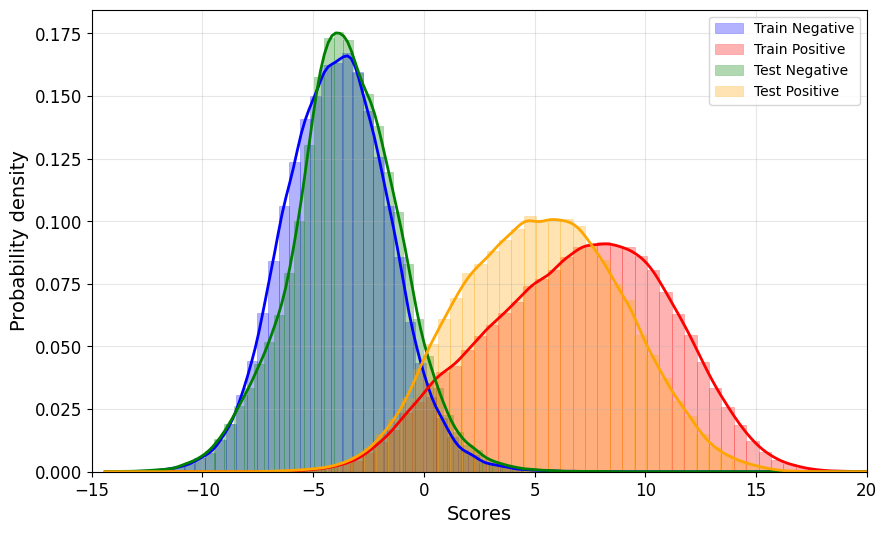

In [16]:
plot_score_distribution(
    train_scores, train_labels,
    test_scores, test_labels,
    filename="score_dist_comparison",
    bins=50,
    xlim=(-15, 20),
    show_kde=True
)

# Conditional Normalizing Flow (1D)

In [47]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

class ConditionalCouplingLayer(nn.Module):
    def __init__(self, dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.dim = dim
        self.d = dim // 2

        self.scale_net = nn.Sequential(
            nn.Linear(self.d + feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim - self.d),
            nn.Tanh()
        )

        self.translate_net = nn.Sequential(
            nn.Linear(self.d + feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim - self.d)
        )

    def forward(self, x, features, reverse=False):
        x1, x2 = x[:, :self.d], x[:, self.d:]
        cond_input = torch.cat([x1, features], dim=1)

        if not reverse:
            s = self.scale_net(cond_input)
            t = self.translate_net(cond_input)

            z2 = x2 * torch.exp(s) + t
            z = torch.cat([x1, z2], dim=1)

            log_det = torch.sum(s, dim=1)
            return z, log_det
        else:
            s = self.scale_net(cond_input)
            t = self.translate_net(cond_input)

            x2 = (x2 - t) * torch.exp(-s)
            x = torch.cat([x1, x2], dim=1)

            log_det = -torch.sum(s, dim=1)
            return x, log_det

class ConditionalNormalizingFlow(nn.Module):    
    def __init__(self, n_flows=8, feature_dim=128, hidden_dim=64):
        super().__init__()
        self.input_dim = 2
        self.n_flows = n_flows
        
        self.flows = nn.ModuleList([
            ConditionalCouplingLayer(self.input_dim, feature_dim, hidden_dim)
            for _ in range(n_flows)
        ])
    
    def forward(self, scores, features, reverse=False):
        if scores.shape[1] == 1:
            x = torch.cat([scores, torch.zeros_like(scores)], dim=1)
        else:
            x = scores
        log_det_total = 0
        if not reverse:
            for i, flow in enumerate(self.flows):
                x, log_det = flow(x, features, reverse=False)
                log_det_total += log_det
                if i < len(self.flows) - 1:
                    x = x.flip(dims=[1])
            return x, log_det_total
        else:
            for i, flow in enumerate(reversed(self.flows)):
                if i > 0:
                    x = x.flip(dims=[1])
                x, log_det = flow(x, features, reverse=True)
                log_det_total += log_det
            return x[:, 0:1], log_det_total
    
    def log_prob(self, scores, features):
        z, log_det = self.forward(scores, features, reverse=False)
        log_pz = -0.5 * torch.sum(z ** 2, dim=1) - 0.5 * self.input_dim * torch.log(torch.tensor(2 * 3.14159))
        return log_pz + log_det
    
    def sample(self, features, n_samples=1):
        batch_size = features.shape[0]
        device = features.device
        z = torch.randn(batch_size, self.input_dim).to(device)
        with torch.no_grad():
            scores, _ = self.forward(z, features, reverse=True)
        return scores.squeeze()

    def train_flow(self, score_dataset, epochs=20, lr=1e-3, device='cuda'):
        train_loader = DataLoader(score_dataset, batch_size=256, shuffle=True)
        
        optimizer = torch.optim.Adam(self.flows.parameters(), lr=lr)

        for epoch in range(epochs):
            total_loss = 0
            n_batches = 0

            for cnn_scores, features, target_decoy, labels in train_loader:
                features = features.to(device)
                target_decoy = target_decoy.to(device)
                log_prob = self.log_prob(target_decoy, features.to(device))
                loss = -log_prob.mean()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                n_batches += 1

            if (epoch + 1) % 1 == 0:
                avg_loss = total_loss / max(n_batches, 1)
                print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
        return self

    def generate_decoys(self, score_dataset, device='cuda'):
        test_cnn_scores = []
        test_labels = []
        separate_decoy_scores = []
        test_loader = DataLoader(score_dataset, batch_size=256, shuffle=False)

        with torch.no_grad():
            for cnn_scores, features, target_decoy, labels in test_loader:
                features = features.to(DEVICE)
                decoy_scores = self.sample(features)
                separate_decoy_scores.append(decoy_scores.cpu().numpy())
                test_cnn_scores.append(cnn_scores.cpu().numpy())
                test_labels.append(labels.cpu().numpy())

        separate_decoy_scores = np.concatenate(separate_decoy_scores, axis=0)
        test_cnn_scores = np.concatenate(test_cnn_scores, axis=0).flatten()
        test_labels = np.concatenate(test_labels, axis=0)
        return test_cnn_scores, separate_decoy_scores, test_labels

In [48]:
print("Training Normalizing Flow...")
flow_model = ConditionalNormalizingFlow(n_flows=15, feature_dim=256, hidden_dim=64).to(DEVICE)
flow_model = flow_model.train_flow(train_score_dataset, epochs=5, lr=1e-3, device=DEVICE)
scores_flow, decoys_flow, labels_flow = flow_model.generate_decoys(test_score_dataset, device='cuda')

Training Normalizing Flow...
Epoch 1/5, Loss: -4.4622
Epoch 2/5, Loss: -5.6109
Epoch 3/5, Loss: -4.9413
Epoch 4/5, Loss: -5.7207
Epoch 5/5, Loss: -5.3516


In [49]:
def plot_score_distributions(model_scores, decoy_scores, labels, method_name, bins=50):
    fig, ax = plt.subplots(figsize=(10, 6))

    null_scores = model_scores[labels == 0]
    positive_scores = model_scores[labels == 1]

    ax.hist(null_scores, bins=bins, alpha=0.5, label='True Null (Negative Class)',
            color='red', density=True, edgecolor='black', linewidth=0.5)
    ax.hist(decoy_scores, bins=bins, alpha=0.5, label='Generated Decoys',
            color='blue', density=True, edgecolor='black', linewidth=0.5)
    ax.hist(positive_scores, bins=bins, alpha=0.3, label='Positive Class',
            color='green', density=True, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Score', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Score Distribution Analysis - {method_name}', fontsize=16, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [30]:
def plot_score_distributions_with_train(model_scores, decoy_scores, labels, method_name, bins=50):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    null_scores = model_scores[labels == 0]
    positive_scores = model_scores[labels == 1]

    # Отрисовка всех распределений
    ax.hist(null_scores, bins=bins, alpha=0.4, label='True Null (Negative Class)',
            color='red', density=True, edgecolor='black', linewidth=0.5)
    
    ax.hist(TRAIN_NULL_SCORES, bins=bins, alpha=0.4, label='Train Null Scores',
            color='orange', density=True, edgecolor='black', linewidth=0.5)
    
    ax.hist(decoy_scores, bins=bins, alpha=0.4, label='Generated Decoys',
            color='blue', density=True, edgecolor='black', linewidth=0.5)
    
    ax.hist(positive_scores, bins=bins, alpha=0.3, label='Positive Class',
            color='green', density=True, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Score', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'Score Distribution Analysis - {method_name}', fontsize=16, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Использование


In [50]:
import matplotlib.pyplot as plt
import numpy as np

def plot_score_differences(scores_diff, decoys_diff, labels, title="Score Differences Comparison"):
    plt.figure(figsize=(8, 8))
    
    # Split data by labels
    mask_null = (labels == 0)
    mask_positive = (labels == 1)
    
    # Plot points with different colors
    plt.scatter(scores_diff[mask_null], decoys_diff[mask_null], 
                color='blue', alpha=0.5, label='Negative Class (0)')
    plt.scatter(scores_diff[mask_positive], decoys_diff[mask_positive], 
                color='red', alpha=0.5, label='Positive Class (1)')
    
    # Plot diagonal line (x = y)
    min_val = min(np.min(scores_diff), np.min(decoys_diff))
    max_val = max(np.max(scores_diff), np.max(decoys_diff))
    plt.plot([min_val, max_val], [min_val, max_val], 
             'k--', linewidth=1, label='x = y')
    
    # Add labels and title
    plt.xlabel('Original Scores Difference', fontsize=12)
    plt.ylabel('Decoy Scores Difference', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [51]:
scores_flow_train, decoys_flow_train, labels_flow_train = flow_model.generate_decoys(train_score_dataset, device='cuda')

In [52]:
TRAIN_NULL_SCORES = scores_flow_train[labels_flow_train == 0]

In [53]:
scores_flow_train.shape

(179394,)

In [54]:
labels_flow_train.shape

(179394,)

In [55]:
decoys_flow_train

array([-1.8814772,  0.4289239, -3.323699 , ..., -4.2555003, -2.1988268,
       -6.4440866], dtype=float32)

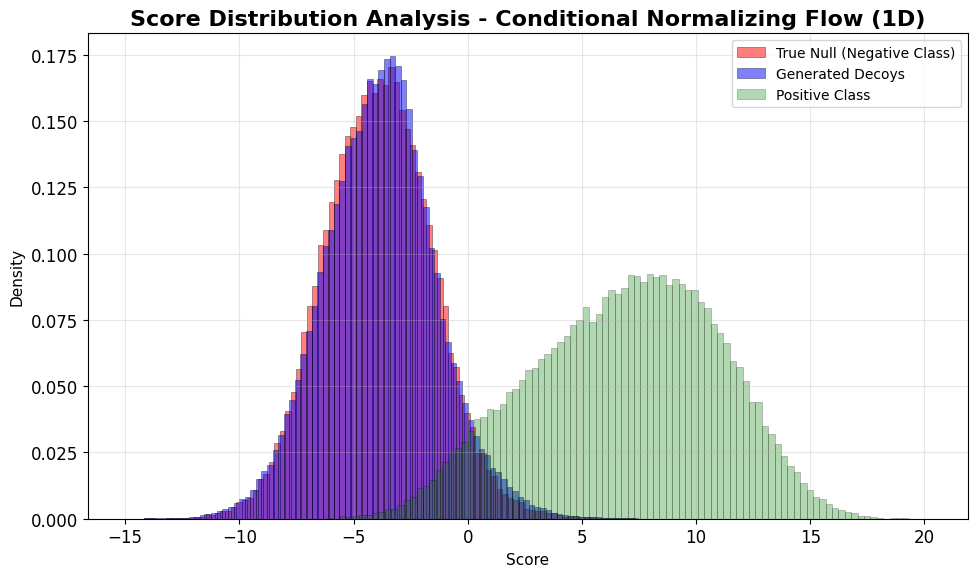

In [56]:
plot_score_distributions(scores_flow_train, decoys_flow_train, labels_flow_train, 'Conditional Normalizing Flow (1D)', bins=100)

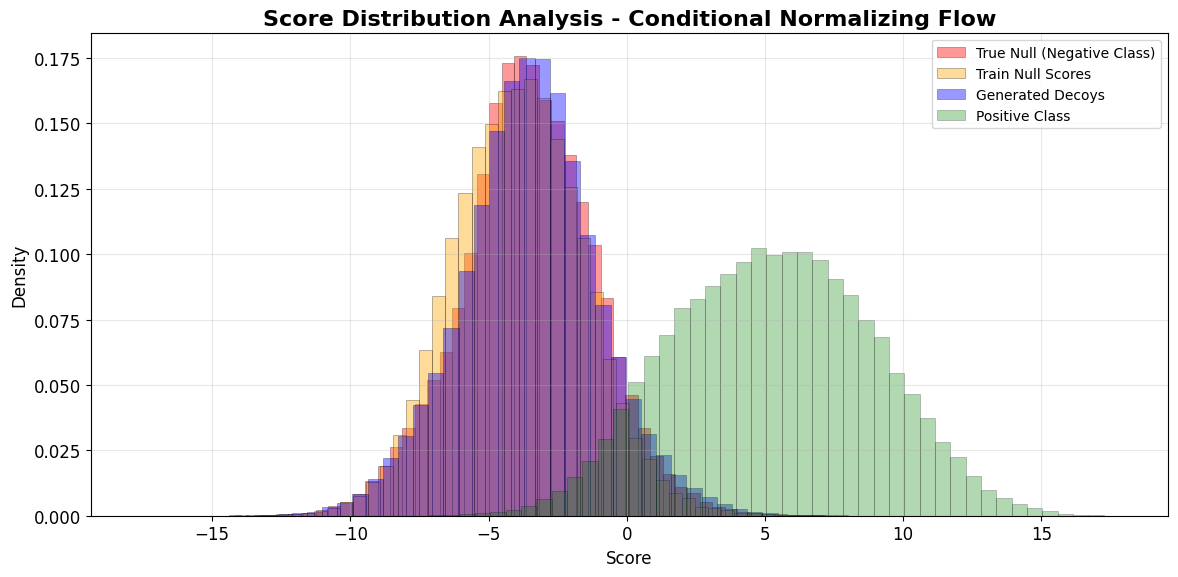

In [57]:
plot_score_distributions_with_train(scores_flow, decoys_flow, labels_flow, 
                         method_name="Conditional Normalizing Flow")

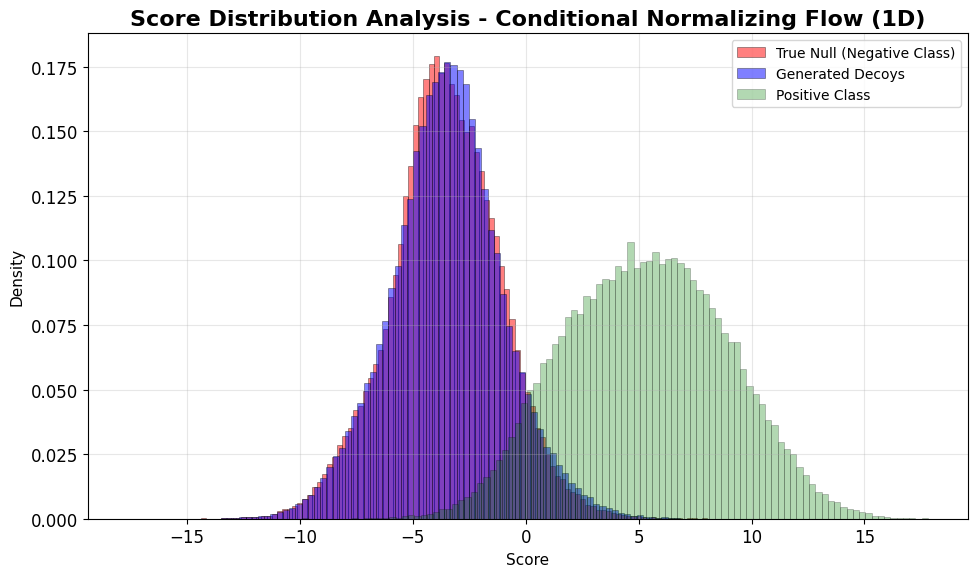

In [58]:
plot_score_distributions(scores_flow, decoys_flow, labels_flow, 'Conditional Normalizing Flow (1D)', bins=100)

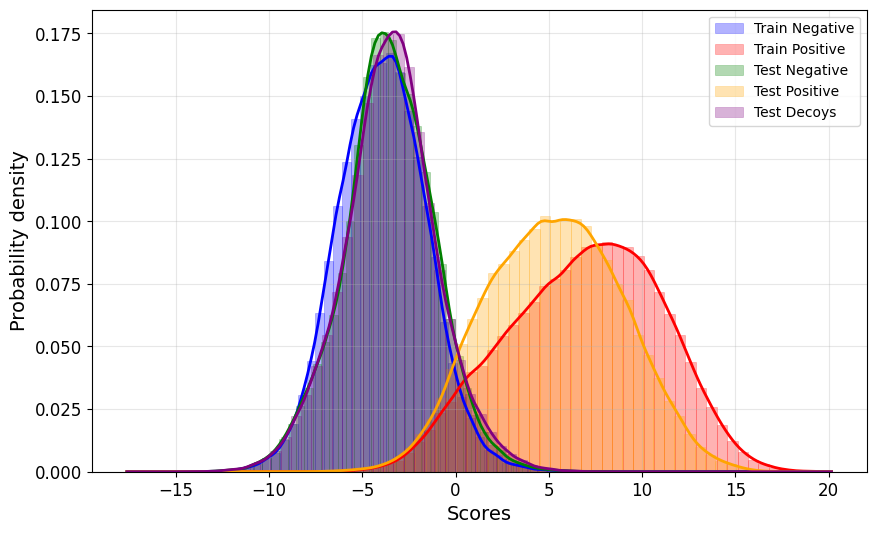

In [59]:
plot_score_distribution_with_decoys(scores_flow_train, labels_flow_train, 
                                        scores_flow, labels_flow, 
                                        decoys_flow,
                                        filename="score_distribution_decoys", 
                                        title="Score Distribution with Decoys",
                                        bins=50, xlim=None, show_kde=True)

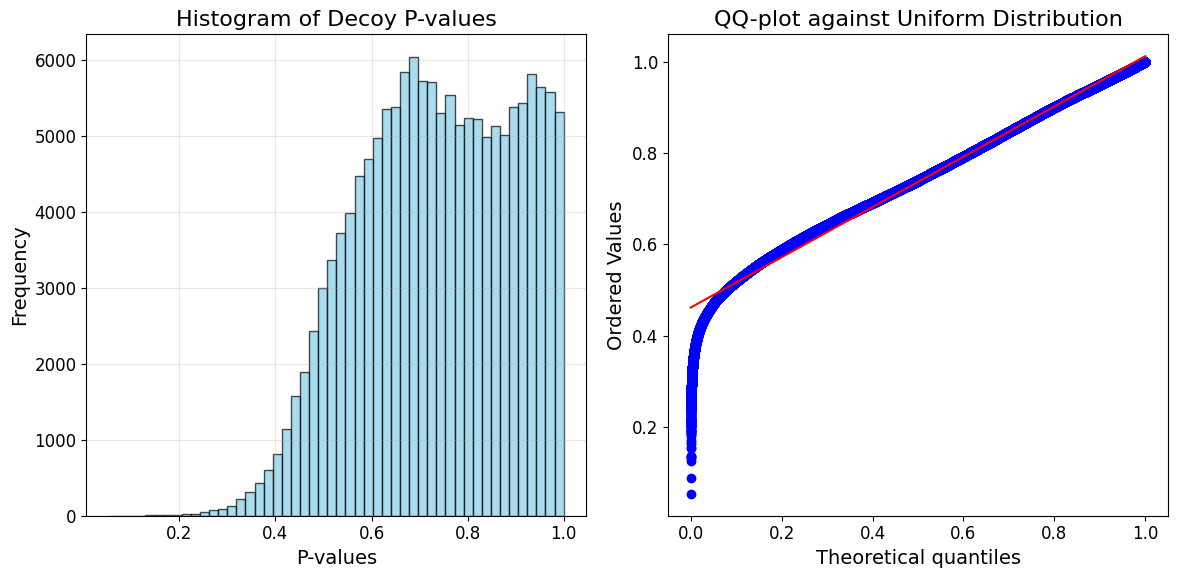

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from bisect import bisect

def empirical_p_values(distribution, query):
    """empirical p-value calculation"""
    dist_len = len(distribution)
    query_len = len(query)
    p_values = np.zeros(query_len)

    for i, score in enumerate(query):
        p_values[i] = (dist_len - bisect(distribution, score)) / dist_len
    
    return p_values

# Вычислим p-значения для декаев
p_values_decoy = empirical_p_values(np.sort(scores_flow), decoys_flow)

# Построим гистограмму
plt.figure(figsize=(12, 6))

# Гистограмма p-значений
plt.subplot(1, 2, 1)
plt.hist(p_values_decoy, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('P-values')
plt.ylabel('Frequency')
plt.title('Histogram of Decoy P-values')
plt.grid(True, alpha=0.3)

# QQ-plot для проверки равномерности
plt.subplot(1, 2, 2)
stats.probplot(p_values_decoy, dist="uniform", plot=plt)
plt.title('QQ-plot against Uniform Distribution')

plt.tight_layout()
plt.show()

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests
from bisect import bisect
import os
from sklearn.neighbors import KernelDensity



def empirical_p_values(distribution, query):
    dist_len = len(distribution)
    query_len = len(query)
    p_values = np.zeros(query_len)
    sorted_dist = np.sort(distribution)
    for i, score in enumerate(query):
        p_values[i] = (dist_len - bisect(sorted_dist, score)) / dist_len

    return p_values


def estimate_pi0_storey(p_values, lambda_range=np.arange(0.05, 0.95, 0.05)):
    pi0_estimates = []
    for lam in lambda_range:
        pi0_lam = np.mean(p_values > lam) / (1 - lam)
        pi0_estimates.append(pi0_lam)
    pi0 = np.mean(pi0_estimates)
    return min(1.0, max(0, pi0))


def benjamini_hochberg_storey(p_values):
    n = len(p_values)
    pi0 = estimate_pi0_storey(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_p = p_values[sorted_indices]
    q_values = np.zeros(n)
    prev_min = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        q_value = pi0 * sorted_p[i] * n / rank
        q_value = min(q_value, prev_min)
        q_values[sorted_indices[i]] = q_value
        prev_min = q_value

    return q_values


def benjamini_hochberg_fixed(p_values, pi0=1.0):
    n = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_p = p_values[sorted_indices]
    q_values = np.zeros(n)
    prev_min = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        q_value = pi0 * sorted_p[i] * n / rank
        q_value = min(q_value, prev_min)
        q_values[sorted_indices[i]] = q_value
        prev_min = q_value

    return q_values


def calculate_qvalues_from_pvalues(distribution, query, pi_0=0.9):
    p_values = empirical_p_values(np.sort(distribution), query)
    q_values = p_values * len(p_values) * pi_0
    q_values = q_values / np.arange(1, len(p_values) + 1)
    for i in range(len(p_values)-1, 0, -1):
        q_values[i-1] = min(q_values[i-1], q_values[i])
    return np.sort(q_values)


def negative_training_benchmark(train_cnn_scores, train_labels, test_cnn_scores,
                                target_class, fdr_level=0.05):
    neg_train_mask = (train_labels != target_class)
    null_distribution = train_cnn_scores[neg_train_mask]
    test_scores = test_cnn_scores
    p_values = empirical_p_values(null_distribution, test_scores)
    q_values = benjamini_hochberg_storey(np.sort(p_values))
    n_discoveries = (q_values <= fdr_level).sum()
    return n_discoveries, q_values, p_values


def control_fdr(model_scores, target_labels, decoys,
                train_cnn_scores=None, train_labels=None,
                test_cnn_scores=None, target_class=None):
    df = pd.DataFrame({
        'model_score': model_scores,
        'label': target_labels,
        'decoy_score': decoys
    })
    df = df.sort_values(by='model_score', ascending=False, inplace=False).reset_index(drop=True)
    df['fdr'] = 0.0
    num_neg = 0
    num_pos = 0

    for index, row in df.iterrows():
        if row['label'] == 0:
            num_neg += 1
        else:
            num_pos += 1
        df.at[index, 'fdr'] = (num_neg + 1.0) / (num_pos + num_neg)


    df['q_values_ground_truth'] = df['fdr'].copy()
    prev = 1
    for index in range(len(df) - 1, -1, -1):
        df.loc[index, 'q_values_ground_truth'] = min(prev, df.loc[index, 'q_values_ground_truth'])
        prev = df.loc[index, 'q_values_ground_truth']

    df['max_score'] = df[['model_score', 'decoy_score']].max(axis=1)
    df = df.sort_values(by='max_score', ascending=False).reset_index(drop=True)

    df['fdr'] = 0.0

    num_neg = 0
    num_pos = 0

    for index, row in df.iterrows():
        if row['model_score'] < row['decoy_score']:
            num_neg += 1
        else:
            num_pos += 1
        df.loc[index, 'fdr'] = (2 * num_neg + 1.0) / (num_pos + num_neg)

    df['q_values_tdc'] = df['fdr'].copy()
    prev = 1.0
    for index in range(len(df) - 1, -1, -1):
        df.loc[index, 'q_values_tdc'] = min(prev, df.loc[index, 'q_values_tdc'])
        prev = df.loc[index, 'q_values_tdc']

    df['p_value'] = empirical_p_values(np.sort(decoys), model_scores)

    df['q_values_bh_storey'] = benjamini_hochberg_storey(np.sort(df['p_value']))
    df['q_values_bh_fixed'] = benjamini_hochberg_fixed(np.sort(df['p_value']))

    if (train_cnn_scores is not None and train_labels is not None and
        test_cnn_scores is not None and target_class is not None):
        n_discoveries_neg, q_values_neg, p_values_neg = negative_training_benchmark(
            train_cnn_scores, train_labels, test_cnn_scores, target_class
        )
        df['q_values_negative_training'] = q_values_neg
        df['p_values_negative_training'] = p_values_neg
    return df



def plot_fdr_comprehensive(df):
    """Comprehensive FDR plot with all methods"""
    plt.figure(figsize=(14, 10))
    
    methods = [
        ('q_values_tdc', 'TDC', 'blue', '-'),
        ('q_values_ground_truth', 'Ground Truth', 'green', '-'),
        ('q_values_bh_storey', 'BH (Storey π₀)', 'red', '-'),
    ]
    if 'q_values_negative_training' in df.columns:
        methods.append(('q_values_negative_training', 'Negative Training', 'orange', ':'))
    
    for col_name, label, color, linestyle in methods:  # unpack 4
        df_sorted = df.sort_values(by=col_name, ascending=True).reset_index(drop=True)
        plt.plot(df_sorted[col_name], np.arange(len(df_sorted)), 
                marker='none', linestyle=linestyle, label=label, linewidth=2, color=color)
    
    plt.ylabel('Number of Discoveries')
    plt.xlabel('Q-values')
    plt.title('Comparison of FDR Control Methods')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xlim(0, 1)
    
    return plt

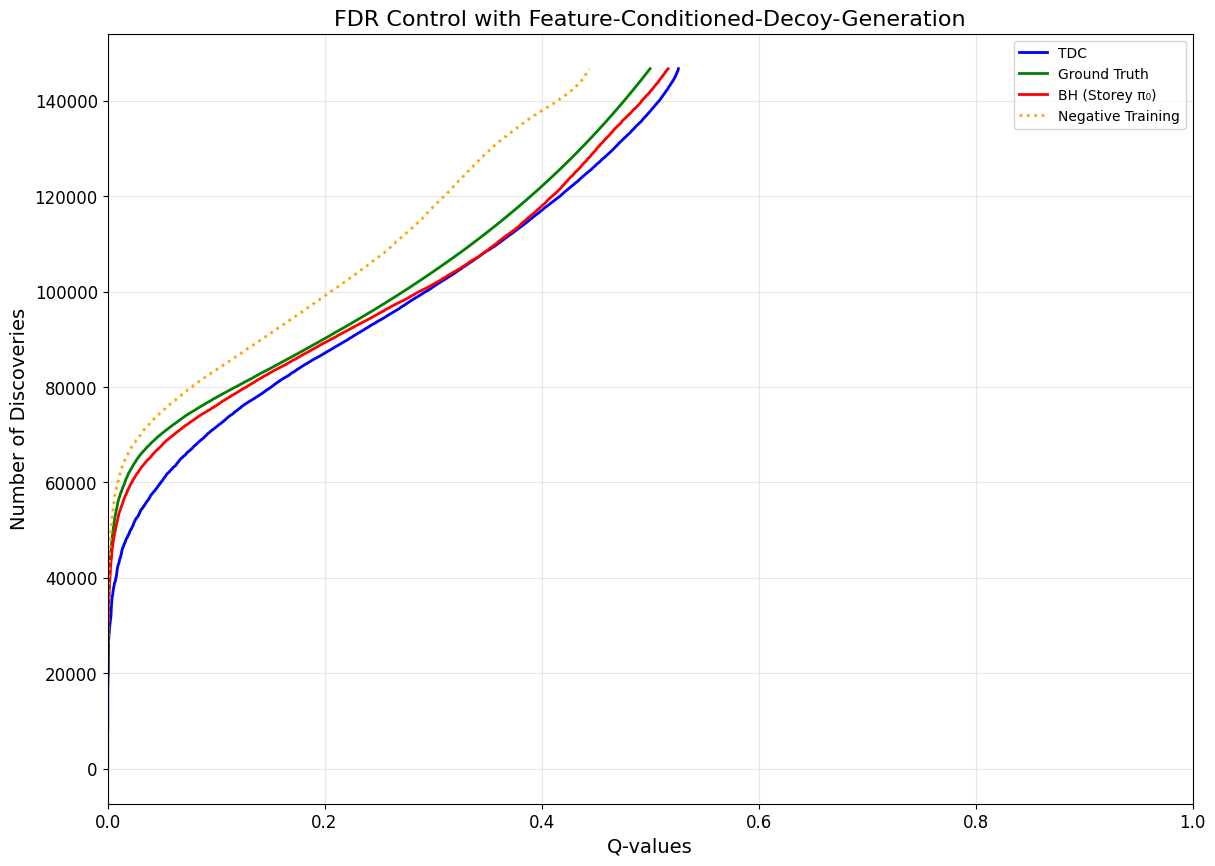

In [72]:
df_flow = control_fdr(scores_flow, labels_flow, decoys_flow, scores_flow_train.flatten(), labels_flow_train,
                scores_flow, target_class=1)
plot_fdr_comprehensive(df_flow)
plt.title('FDR Control with Feature-Conditioned-Decoy-Generation')
plt.show()

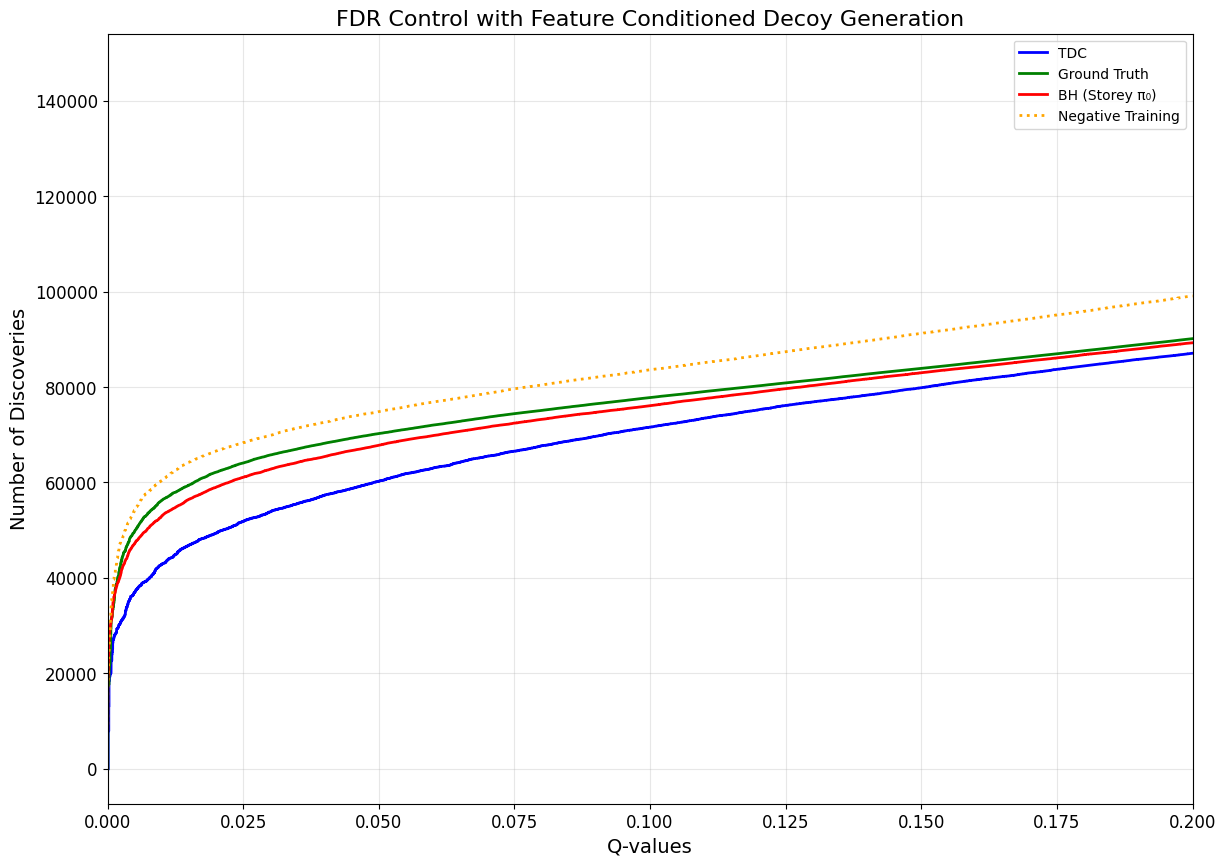

In [76]:
plot_fdr_comprehensive(df_flow)
plt.title('FDR Control with Feature Conditioned Decoy Generation')
plt.xlim(0, 0.2)
plt.savefig('fdr_control_flow_сamelyon_02.png', dpi=300, bbox_inches='tight')
plt.savefig('fdr_control_flow_сamelyon_02.pdf', bbox_inches='tight')
plt.show()

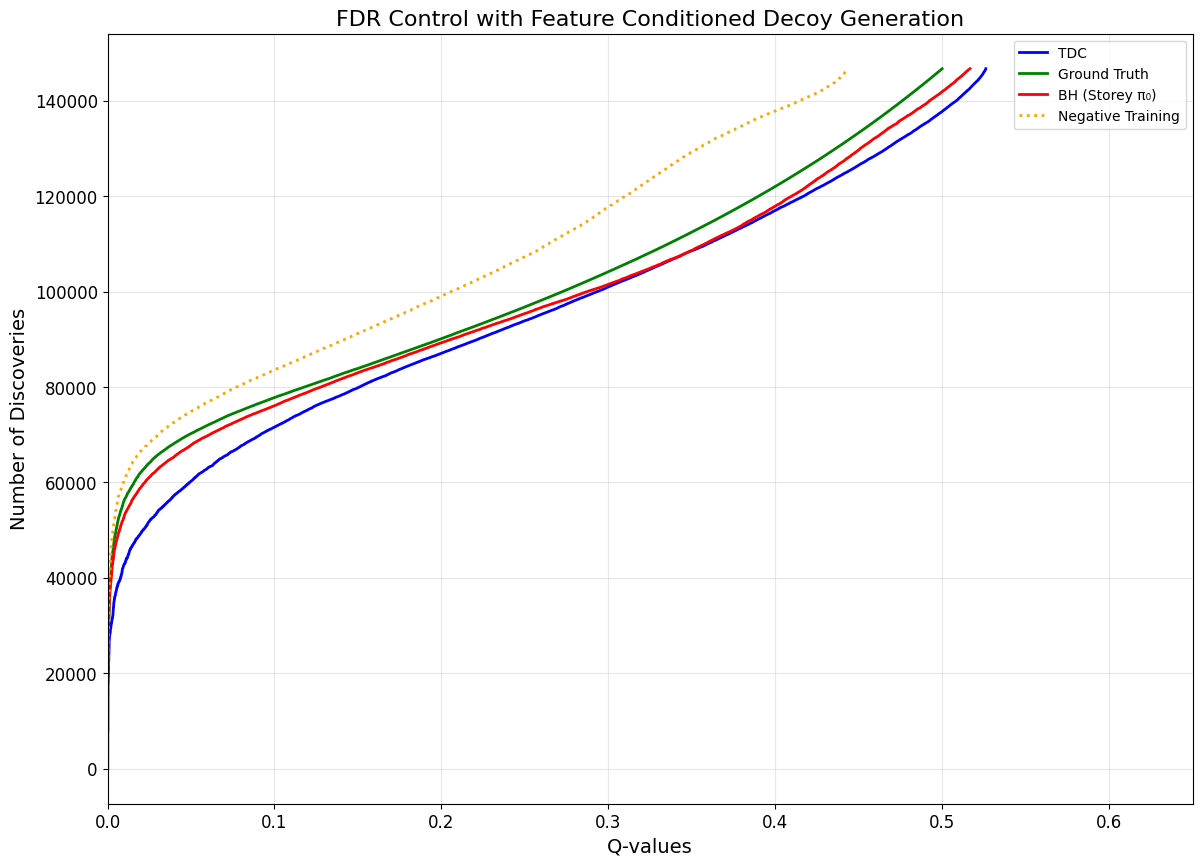

In [77]:
plot_fdr_comprehensive(df_flow)
plt.title('FDR Control with Feature Conditioned Decoy Generation')
plt.xlim(0, 0.65)
plt.savefig('fdr_control_flow_сamelyon_065.png', dpi=300, bbox_inches='tight')
plt.savefig('fdr_control_flow_сamelyon_065.pdf', bbox_inches='tight')
plt.show()